In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("Classification_Task3_Data.csv")

print(df)

    Age  Income  Credit_Score  Loan_Amount Previous_Default  Employment_Years  \
0    22   25000           580       100000              Yes                 1   
1    25   32000           650       150000               No                 3   
2    28   40000           720       200000               No                 5   
3    31   45000           690       250000               No                 6   
4    35   52000           610       300000              Yes                 4   
5    38   60000           750       350000               No                10   
6    42   70000           680       400000               No                12   
7    45   48000           590       280000              Yes                 7   
8    24   28000           620       120000               No                 2   
9    30   35000           570       180000              Yes                 4   
10   33   50000           710       220000               No                 8   
11   27   30000           56

In [3]:
df.head()

,Age,Income,Credit_Score,Loan_Amount,Previous_Default,Employment_Years,Loan_Status
0,22,25000,580,100000,Yes,1,Rejected
1,25,32000,650,150000,No,3,Approved
2,28,40000,720,200000,No,5,Approved
3,31,45000,690,250000,No,6,Approved
4,35,52000,610,300000,Yes,4,Rejected


In [4]:
df.tail()

,Age,Income,Credit_Score,Loan_Amount,Previous_Default,Employment_Years,Loan_Status
10,33,50000,710,220000,No,8,Approved
11,27,30000,560,130000,Yes,2,Rejected
12,40,65000,740,380000,No,11,Approved
13,29,42000,670,210000,No,6,Approved
14,36,55000,600,320000,Yes,5,Rejected


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               15 non-null     int64 
 1   Income            15 non-null     int64 
 2   Credit_Score      15 non-null     int64 
 3   Loan_Amount       15 non-null     int64 
 4   Previous_Default  15 non-null     object
 5   Employment_Years  15 non-null     int64 
 6   Loan_Status       15 non-null     object
dtypes: int64(5), object(2)
memory usage: 972.0+ bytes


In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (15, 7)


In [7]:
df.shape

(15, 7)

In [8]:
df.columns

Index(['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Previous_Default',
       'Employment_Years', 'Loan_Status'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               15 non-null     int64 
 1   Income            15 non-null     int64 
 2   Credit_Score      15 non-null     int64 
 3   Loan_Amount       15 non-null     int64 
 4   Previous_Default  15 non-null     object
 5   Employment_Years  15 non-null     int64 
 6   Loan_Status       15 non-null     object
dtypes: int64(5), object(2)
memory usage: 972.0+ bytes


In [10]:
df.describe()

,Age,Income,Credit_Score,Loan_Amount,Employment_Years
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,32.333333,45133.333333,649.333333,239333.333333,5.733333
std,6.872998,13757.422239,64.083279,96248.685829,3.348063
min,22.000000,25000.000000,560.000000,100000.000000,1.000000
25%,27.500000,33500.000000,595.000000,165000.000000,3.500000
50%,31.000000,45000.000000,650.000000,220000.000000,5.000000
75%,37.000000,53500.000000,700.000000,310000.000000,7.500000
max,45.000000,70000.000000,750.000000,400000.000000,12.000000


In [24]:
X = df[['Age']]
y = df['Income']

In [ ]:
# PART A
# Linear Regression (Sklearn)

In [25]:
# Split Dataset (80% Train, 20% Test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12, 1)
Testing data: (3, 1)


In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 1569.5476029709655
Intercept: -4186.36056718434


In [29]:
age = pd.DataFrame({'Age':[30]})
prediction = model.predict(age)

In [30]:
print("Predicted Income for Age 30:", prediction[0])

Predicted Income for Age 30: 42900.06752194463


In [31]:
print("Actual Income")
print(y_test.values)

print()

print("Predicted Income")
print(y_pred)

Actual Income
[35000 30000 25000]

Predicted Income
[42900.06752194 38191.42471303 30343.68669818]


In [ ]:
# Part B: Gradient Descent from Scratch

In [36]:
X_train = X_train.values.flatten().astype(float)
y_train = y_train.values.astype(float)

X_test = X_test.values.flatten().astype(float)
y_test = y_test.values.astype(float)

n = len(X_train)

# Initialize Parameters
m = 0.0
c = 0.0

lr = 0.0001
epochs = 20000

loss_history = []

# Gradient Descent
for i in range(epochs):

    y_pred_train = m * X_train + c

    error = y_pred_train - y_train

    loss = (1/n) * np.sum(error ** 2)

    loss_history.append(loss)

    dm = (2/n) * np.sum(error * X_train)

    dc = (2/n) * np.sum(error)

    m = m - lr * dm

    c = c - lr * dc

    if i % 4000 == 0:
        print(f"Epoch {i}: Loss={loss:.2f}  m={m:.3f}  c={c:.3f}")

print("\nFinal Parameters")
print("Slope (m):", m)
print("Intercept (c):", c)

Epoch 0: Loss=2537916666.67  m=343.917  c=9.783
Epoch 4000: Loss=44318183.67  m=1452.222  c=-74.316
Epoch 8000: Loss=44286534.68  m=1455.431  c=-186.781
Epoch 12000: Loss=44256593.23  m=1458.552  c=-296.170
Epoch 16000: Loss=44228267.19  m=1461.588  c=-402.567

Final Parameters
Slope (m): 1464.539980172953
Intercept (c): -506.02856490943026


In [37]:
# Prediction on Test Data
y_pred_test = m * X_test + c

# Mean Squared Error
mse = np.mean((y_test - y_pred_test) ** 2)

print("Gradient Descent Test MSE:", mse)

# Predict for Age = 30
age = 30
income = m * age + c

print("Predicted Income for Age 30:", income)

Gradient Descent Test MSE: 65934275.93187409
Predicted Income for Age 30: 43430.170840279156


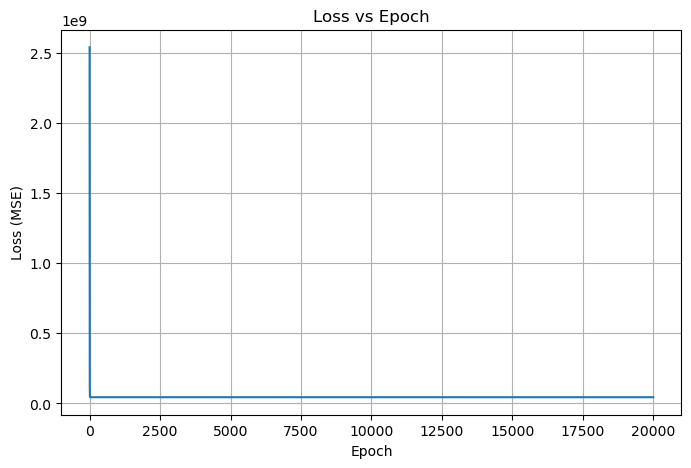

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epoch")
plt.grid(True)
plt.show()

In [42]:
print("---------- Comparison ----------")

print("Sklearn Slope :", model.coef_[0])
print("Gradient Descent Slope :", m)

print()

print("Sklearn Intercept :", model.intercept_)
print("Gradient Descent Intercept :", c)

---------- Comparison ----------
Sklearn Slope : 1569.5476029709655
Gradient Descent Slope : 1464.539980172953

Sklearn Intercept : -4186.36056718434
Gradient Descent Intercept : -506.02856490943026
